In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargamos el dataset directamente desde la fuente oficial
url = "https://github.com/owid/energy-data/raw/master/owid-energy-data.csv"
df = pd.read_csv(url)

# Filtramos para ver los datos más recientes (ej. desde el año 2000)
df = df[df['year'] >= 2000]

print(f"Dataset cargado con {df.shape[0]} filas y {df.shape[1]} columnas.")

Dataset cargado con 7491 filas y 130 columnas.


In [3]:
print(df_paises.columns)


Index(['country', 'year', 'iso_code', 'population', 'gdp',
       'biofuel_cons_change_pct', 'biofuel_cons_change_twh',
       'biofuel_cons_per_capita', 'biofuel_consumption',
       'biofuel_elec_per_capita',
       ...
       'solar_share_elec', 'solar_share_energy', 'wind_cons_change_pct',
       'wind_cons_change_twh', 'wind_consumption', 'wind_elec_per_capita',
       'wind_electricity', 'wind_energy_per_capita', 'wind_share_elec',
       'wind_share_energy'],
      dtype='str', length=130)


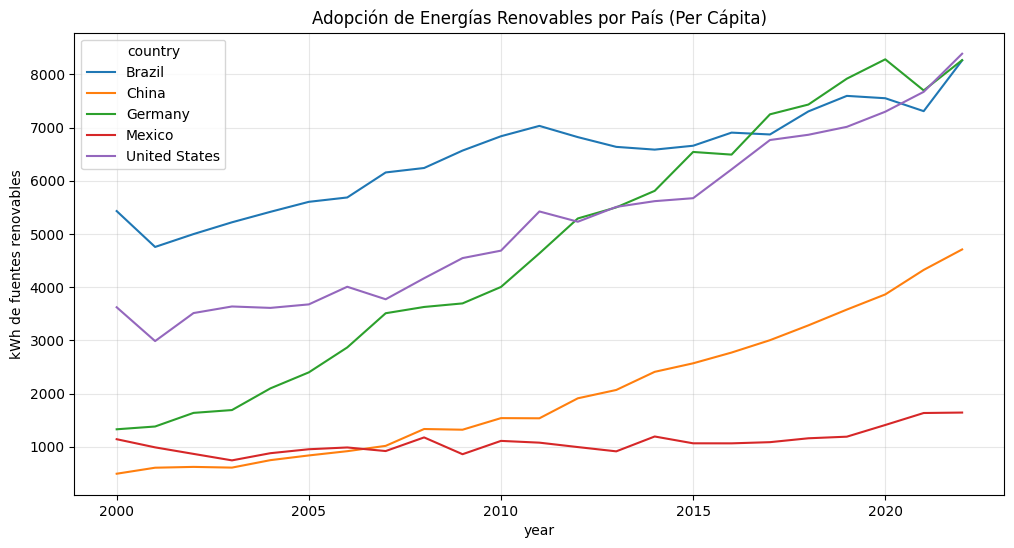

In [8]:
# 2. Filtrar por años recientes y países específicos
paises = ['Mexico', 'United States', 'Germany', 'China', 'Brazil']
# En este dataset, la columna de PIB es 'gdp' y la de población es 'population'
# Las emisiones de CO2 suelen estar en 'carbon_intensity_elec' o 'renewables_energy_per_capita'
# Vamos a usar estas que son las más estándar en su esquema actual:
columnas_reales = [
    'country', 
    'year', 
    'energy_per_capita', 
    'renewables_energy_per_capita', 
    'gdp'
]

# Creamos el subset verificando que existan
df_final = df[df['country'].isin(paises) & (df['year'] >= 2000)][columnas_reales].dropna()

# 3. Visualización: Energía Renovable per cápita
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_final, x='year', y='renewables_energy_per_capita', hue='country')
plt.title('Adopción de Energías Renovables por País (Per Cápita)')
plt.ylabel('kWh de fuentes renovables')
plt.grid(True, alpha=0.3)
plt.savefig('Adopción de Energías Renovables por País (Per Cápita)', dpi=300, bbox_inches='tight')
plt.show()

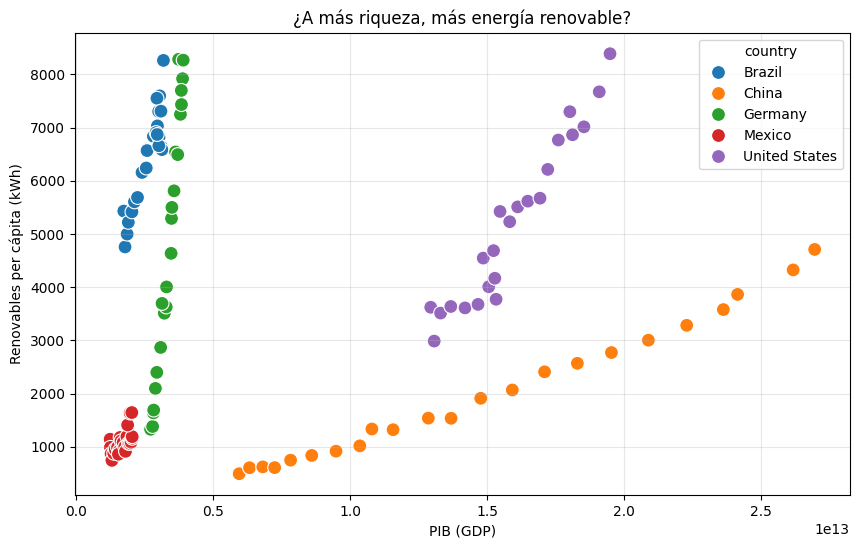

In [12]:
# Vamos a ver la relación entre Riqueza (GDP) y Energía Renovable
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_final, x='gdp', y='renewables_energy_per_capita', hue='country', s=100)

plt.title('¿A más riqueza, más energía renovable?')
plt.xlabel('PIB (GDP)')
plt.ylabel('Renovables per cápita (kWh)')
plt.grid(True, alpha=0.3)
plt.savefig('¿A más riqueza, más energía renovable?', dpi=300, bbox_inches='tight')

plt.show()

/var/folders/4q/d3kpwqg56fx2c6bffcf0bvkc0000gn/T/ipykernel_30256/2078462478.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ultimo_anio_sorted, x='country', y='renewable_share_target', palette='magma')


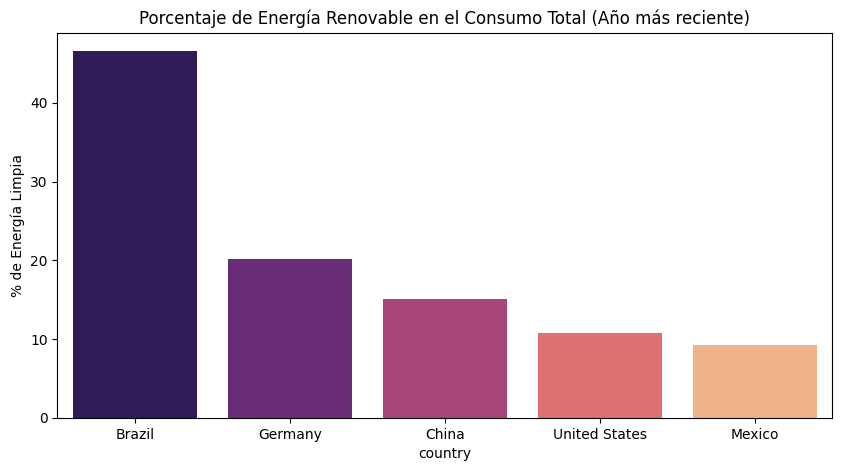

In [7]:
# Creamos la nueva columna
df_final['renewable_share_target'] = (df_final['renewables_energy_per_capita'] / df_final['energy_per_capita']) * 100

# Graficamos el top del último año disponible
ultimo_anio = df_final[df_final['year'] == df_final['year'].max()]
ultimo_anio_sorted = ultimo_anio.sort_values('renewable_share_target', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=ultimo_anio_sorted, x='country', y='renewable_share_target', palette='magma')
plt.title('Porcentaje de Energía Renovable en el Consumo Total (Año más reciente)')
plt.ylabel('% de Energía Limpia')
plt.savefig('Porcentaje de Energía Renovable en el Consumo Total (Año más reciente)', dpi=300, bbox_inches='tight')
plt.show()